In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


#load data 
train_data = pd.read_csv('~/Downloads/titanic/train.csv')
test_data = pd.read_csv('~/Downloads/titanic/test.csv')


print(f"Trian shape: {train_data.shape}")
print(f"Test shape: {test_data.shape}")
print(f"\n Train columns: {train_data.columns.tolist()}")
print(f"Missing values in train: {train_data.isnull().sum()}")

Trian shape: (891, 12)
Test shape: (418, 11)

 Train columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']
Missing values in train: PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [12]:
#clean data( fill age with median and drop cabin and fill embarked with mode)
def clean_data(df):
    #drop useless column
    df = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis = 1)

    #fill missing value
    df['Age'] = df['Age'].fillna(df['Age'].median())
    df['Fare'] = df['Fare'].fillna(df['Fare'].median())
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

    df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
    df['Embarked'] = df['Embarked'].map({'S':0, 'C': 1, 'Q': 2})

    return df

train = clean_data(train_data)
test = clean_data(test_data)

print("Train cleaned:", train.shape)
print("Test cleaned:", test.shape)
print("\n Missing data in train:", train.isnull().sum().sum())
print("\n Missing data in test:", test.isnull().sum().sum())




Train cleaned: (891, 8)
Test cleaned: (418, 7)

 Missing data in train: 0

 Missing data in test: 0


In [14]:
print(test.head())

   Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
0       3    0  34.5      0      0   7.8292         2
1       3    1  47.0      1      0   7.0000         0
2       2    0  62.0      0      0   9.6875         2
3       3    0  27.0      0      0   8.6625         0
4       3    1  22.0      1      1  12.2875         0


/var/folders/96/gbs9hlmd47lg84whxmk4ntwc0000gn/T/ipykernel_83928/1581533408.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Male', 'Female'])


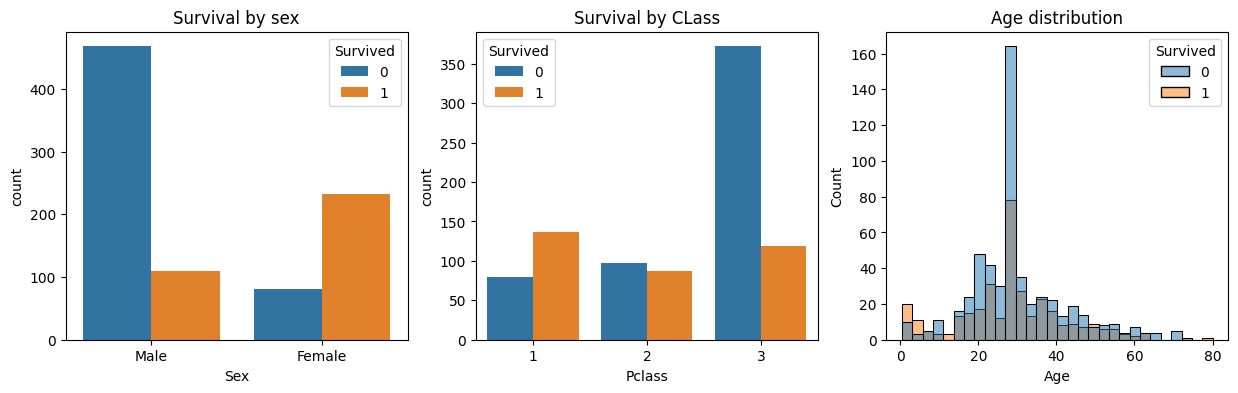

In [15]:
#EDA with seaborn
fig, axes = plt.subplots(1, 3, figsize = (15, 4))

#survival by sex 
sns.countplot(data = train, x = 'Sex', hue = 'Survived', ax = axes[0])
axes[0].set_title("Survival by sex")
axes[0].set_xticklabels(['Male', 'Female'])

#survival by clas
sns.countplot(data = train, x = 'Pclass', hue = 'Survived', ax = axes[1])
axes[1].set_title("Survival by CLass")

#age distribution
sns.histplot(data = train, x = 'Age', hue = 'Survived', ax = axes[2])
axes[2].set_title("Age distribution")

plt.show()



            

In [22]:
def add_features(df):
    #family size:: total famil on board
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

    #is alone or travelling solo
    df['isAlone'] = (df['FamilySize'] == 1).astype(int)

    #Age group: child or adult or senior
    df['AgeGroup'] = pd.cut(df['Age'],
                            bins = [0, 2, 18, 60, 100],
                            labels = [0, 1, 2, 3]).astype(int)
    return df

train = add_features(train)
test = add_features(test)
print(train[['FamilySize', 'isAlone', 'AgeGroup']].head(10))
    

   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked  FamilySize  \
0         0       3    0  22.0      1      0   7.2500         0           2   
1         1       1    1  38.0      1      0  71.2833         1           2   
2         1       3    1  26.0      0      0   7.9250         0           1   
3         1       1    1  35.0      1      0  53.1000         0           2   
4         0       3    0  35.0      0      0   8.0500         0           1   

   isAlone  AgeGroup  
0        0         2  
1        0         2  
2        1         2  
3        0         2  
4        1         2  
   FamilySize  isAlone  AgeGroup
0           2        0         2
1           2        0         2
2           1        1         2
3           2        0         2
4           1        1         2
5           1        1         2
6           1        1         2
7           5        0         0
8           3        0         2
9           2        0         1


In [26]:
#train model
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch',
            'Fare', 'Embarked', 'FamilySize', 'isAlone', 'AgeGroup']
X = train[features]
y = train['Survived']
X_test_kaggle = test[features]

#Build pipeline
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(random_state=42))
])

param_grid = {
    'model__n_estimators': [50, 100, 150],
    'model__max_depth': [4, 5, 6],
    'model__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(pipe, param_grid, cv = 5, scoring = 'accuracy', n_jobs = -1)
grid_search.fit(X, y)

print(f"Best params: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score:.4f}")


Best params: {'model__max_depth': 5, 'model__min_samples_split': 2, 'model__n_estimators': 100}


AttributeError: 'GridSearchCV' object has no attribute 'best_score'